In [6]:
# --- IMPORT STATEMENTS ---

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import healpy as hp

In [7]:
# --- GLOBAL VARIABLES ---

SAVE_FIGS = False

LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
FIGURE_SAVEDIR = "figures" # Aimee
MAPS_DIR = f'{LINUX_DIRECTORY}/data/3D_wcs_maps' # Aimee
MAPS_SAVEDIR = f'{LINUX_DIRECTORY}/data/maps'

EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    "Effelsberg 2.73 GHz" : ['Effelsberg_2.7272GHz_raw.fits'] # raw from website - 3D WCS (code can't handle it)
    # "Effelsberg 2.73 GHz" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits"] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
   "Nobeyama 10 GHz" : ["Nobeyama_10.0GHz_raw.fits"] # raw from website - 3D WCS (code can't handle it)
    # "Nobeyama 10 GHz" : ["NOBEYAMA-10.0GHz-5.0amin.fits"] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    "Parkes 5 GHz" : ["Parkes_5.0GHz_raw.fits"] # raw from website - 3D WCS (code can't handle it)
    # "Parkes 5 GHz" : ["PARKES-5.0GHz-5.0amin.fits"] # CORRUPTED
}

In [8]:
# --- FUNCTION DEFINTIONS ---

def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)

    try: # COMAP
        noise = fits_file[3].data
    except: # if no original data, returns array of nans w/ same shape as data
        noise = np.zeros_like(data) 
        # noise.fill(np.nan) 
        
    return data, noise, header, wcs

In [9]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [mK]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

Getting data from /home/aimee/mphys/data/maps/PARKES-5.0GHz-5.0amin.fits
Getting data from /home/aimee/mphys/data/3D_wcs_maps/Parkes_5.0GHz_raw.fits


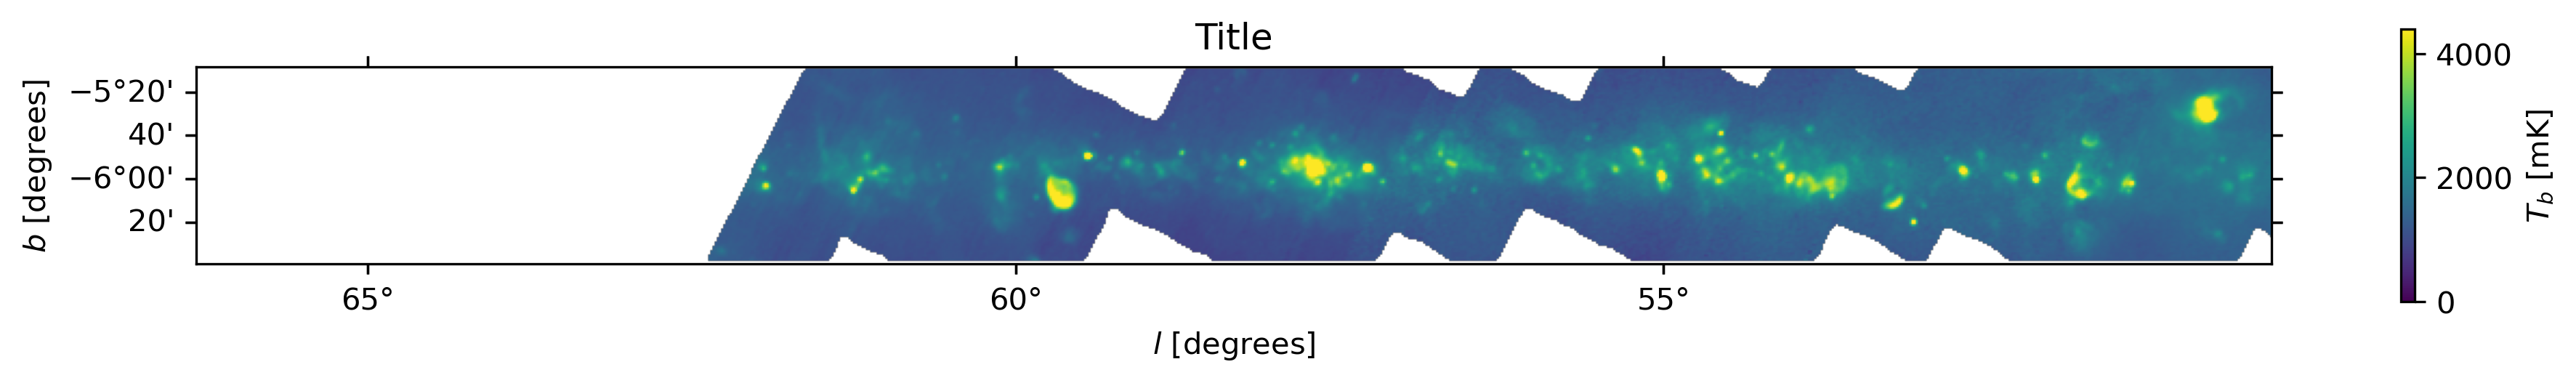

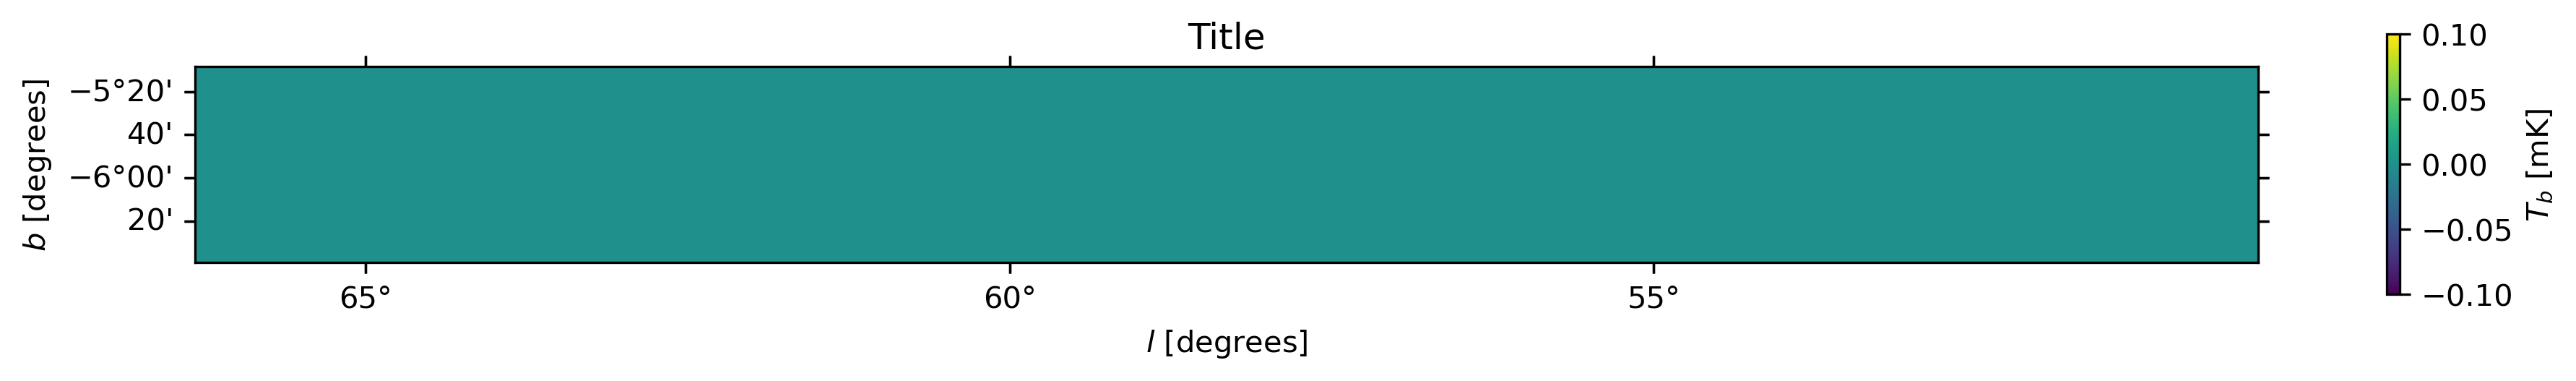

In [ ]:
# --- MAIN CODE --- 

# ATTEMPT 1 - remove extra axis (messes up rest of wcs, including coordinate conversions?) - NO, coordinates wrong

# map_name = "Parkes_5.0GHz_raw.fits"
# map_path = f'{MAPS_DIR}/{map_name}'

# data, noise, header, wcs = get_map(map_path)

# wcs_2d = wcs.sub([0, 1])

# data_2d = data[0, :, :]  # Select the first frequency slice
# noise_2d = noise[0, :, :]

# plot_fits(data_2d, wcs_2d)
# plot_fits(noise_2d, wcs_2d)

# # ATTEMPT 2 - get wcs from TJ Rennie's maps, get data from raw maps - NO, same issue as above
# map_path_rennie = f'{MAPS_SAVEDIR}/PARKES-5.0GHz-5.0amin.fits'
# map_path_raw = f'{MAPS_DIR}/Parkes_5.0GHz_raw.fits'
# _, _, header, wcs = get_map(map_path_rennie)
# data, noise, _, _ = get_map(map_path_raw)
# data = data[0, :, :]
# noise = noise[0, :, :]

# plot_fits(data, wcs)
# plot_fits(noise, wcs)

# ATTEMPT 3 - Astropy reproject (oversample factor 2) then rebin (factor 2)

